intro...

---
# 1. Setup

In [1]:
# install dependencies
!pip install -qq transformer_lens einops matplotlib

In [2]:
%%capture
import torch
import numpy as np
import einops
import matplotlib.pyplot as plt
import os
import warnings
from transformer_lens import HookedTransformer

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


In [4]:
# load GPT-2 Small: ~163M params, 12 layers, 12 heads, d_model=768
# standard sandbox model for mechanistic interpretability research.
model = HookedTransformer.from_pretrained(
    'gpt2',
    center_unembed = True,
    center_writing_weights = True, # these two subtract mean from embedding and unembedding matrices, normalization trick from ELhage et al. (2021), makes residual stream decomposition cleaner, else there will be constant bias term floating through each layer which affects attribution scores
    fold_ln = True, # folds LayerNorm params into surrounding weight matrices so residual stream is truly a linear sum of contributions
    refactor_factored_attn_matrices = True # rewrites attn. weight matrices to make QK and OV more interpretable
).to(DEVICE)
model.eval()

n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model

print(f'Layers: {n_layers}, Heads: {n_heads}, d_model: {d_model}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu
Layers: 12, Heads: 12, d_model: 768
Total parameters: 163,049,041


In [5]:
# sanity check
prompt = 'The Eiffel Tower is located in the city of'
logits, cache = model.run_with_cache(prompt)
probs = torch.softmax(logits[0, -1], dim = -1)
top5 = torch.topk(probs, 5)
print('Top 5 predictions:')
for tok, p in zip(top5.indices, top5.values):
    token_str = model.to_single_str_token(tok.item())
    print(f'  {repr(token_str):15s}  {p.item():.4f}')

Top 5 predictions:
  ' London'        0.0691
  ' Paris'         0.0688
  ' Amsterdam'     0.0403
  ' Berlin'        0.0323
  ' New'           0.0279


> Note: GPT-2 Small ranks London marginally above Paris here. This is due to model's limited factual associations at this very small scale, not an error.

---
# 2. Attention Pattern Visualization

Raw attention patterns across heads in layers 0, 5, and 11. This gives intuition
for the diversity of attention behaviors before formally identifying circuits.
Taxonomy of head types (previous token heads, induction heads, etc.) from
Elhage et al. (2021).

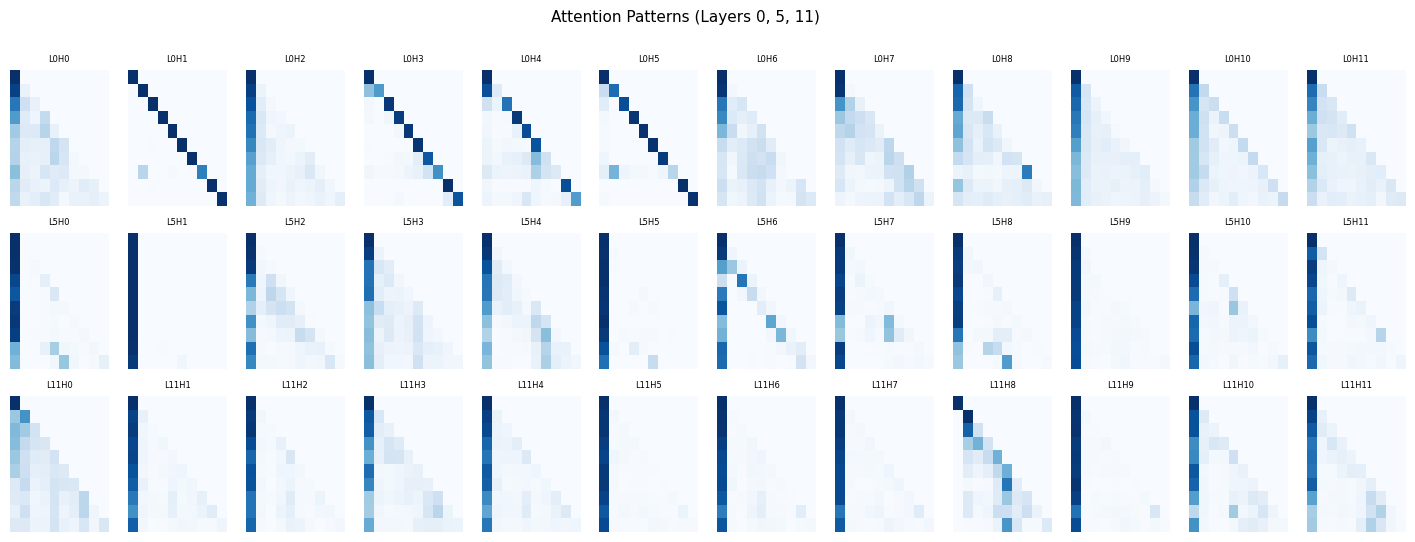

In [6]:
attn_prompt = 'The quick brown fox jumped over the lazy dog'
_, attn_cache = model.run_with_cache(attn_prompt)

target_layers = [0, 5, 11]
fig, axes = plt.subplots(len(target_layers), n_heads, figsize = (n_heads * 1.5, len(target_layers) * 2))
fig.suptitle('Attention Patterns (Layers 0, 5, 11)', fontsize = 11)

for row, layer in enumerate(target_layers):
    # pattern shape: [batch, n_heads, dest_pos, src_pos]
    patterns = attn_cache['pattern', layer][0].cpu().numpy()
    for head in range(n_heads):
        ax = axes[row, head]
        ax.imshow(patterns[head], cmap = 'Blues', vmin = 0, vmax = 1, aspect = 'auto')
        ax.set_title(f'L{layer}H{head}', fontsize = 6)
        ax.axis('off')

plt.savefig('figures/attention_patterns.png', dpi = 120, bbox_inches = 'tight')
plt.show()

---
# 3. Induction Head Detection

intro...

In [7]:
BATCH   = 20
SEQ_LEN = 50

rand_tokens = torch.randint(1000, model.cfg.d_vocab - 1, (BATCH, SEQ_LEN)).to(DEVICE)
repeated    = einops.repeat(rand_tokens, 'b s -> b (2 s)')

induction_scores = torch.zeros(n_layers, n_heads, device = DEVICE)

def induction_hook(pattern, hook):
    # pattern: [batch, head, dest_pos, src_pos]
    # The induction stripe is at offset (1 - SEQ_LEN):
    # for dest position i in the second half, this is src position i - SEQ_LEN + 1,
    # which is the position immediately after the matching token in the first half.
    stripe = pattern.diagonal(dim1 = -2, dim2 = -1, offset = 1 - SEQ_LEN)
    induction_scores[hook.layer()] = einops.reduce(stripe, 'b h p -> h', 'mean')
    # No return value: this is a read-only hook (does not modify activations)

model.run_with_hooks(
    repeated,
    return_type = None,
    fwd_hooks = [(lambda name: name.endswith('pattern'), induction_hook)]
)

scores = induction_scores.cpu().detach().numpy()
print('Induction scores computed.')
print(f'Max score: {scores.max():.3f} at L{scores.argmax() // n_heads}H{scores.argmax() % n_heads}')

Induction scores computed.
Max score: 0.927 at L5H5


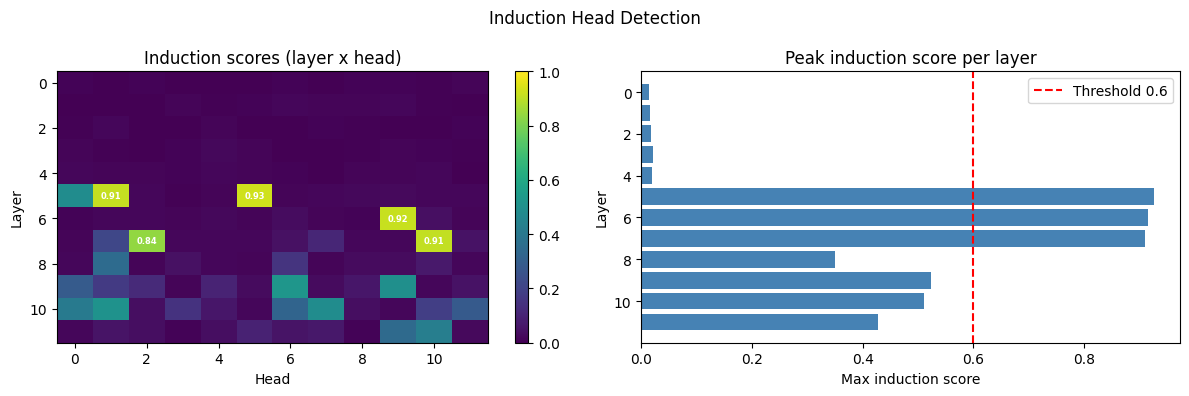

Strong induction heads (score > 0.6):
  L5H1: 0.912
  L5H5: 0.927
  L6H9: 0.916
  L7H2: 0.839
  L7H10: 0.910


In [8]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
fig.suptitle('Induction Head Detection', fontsize = 12)

# Heatmap
im = axes[0].imshow(scores, cmap = 'viridis', vmin = 0, vmax = 1, aspect = 'auto')
axes[0].set_xlabel('Head')
axes[0].set_ylabel('Layer')
axes[0].set_title('Induction scores (layer x head)')
plt.colorbar(im, ax = axes[0])

# Annotate heads above threshold
THRESHOLD = 0.6
for l in range(n_layers):
    for h in range(n_heads):
        if scores[l, h] > THRESHOLD:
            axes[0].text(h, l, f'{scores[l,h]:.2f}', ha = 'center', va = 'center',
                         fontsize = 6, color = 'white', fontweight = 'bold')

# Bar chart: max score per layer
max_per_layer = scores.max(axis = 1)
axes[1].barh(range(n_layers), max_per_layer, color = 'steelblue')
axes[1].invert_yaxis()
axes[1].axvline(THRESHOLD, color = 'red', linestyle = '--', label = f'Threshold {THRESHOLD}')
axes[1].set_xlabel('Max induction score')
axes[1].set_ylabel('Layer')
axes[1].set_title('Peak induction score per layer')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/induction_scores.png', dpi = 120, bbox_inches = 'tight')
plt.show()

print(f'Strong induction heads (score > {THRESHOLD}):')
for l in range(n_layers):
    for h in range(n_heads):
        if scores[l, h] > THRESHOLD:
            print(f'  L{l}H{h}: {scores[l,h]:.3f}')

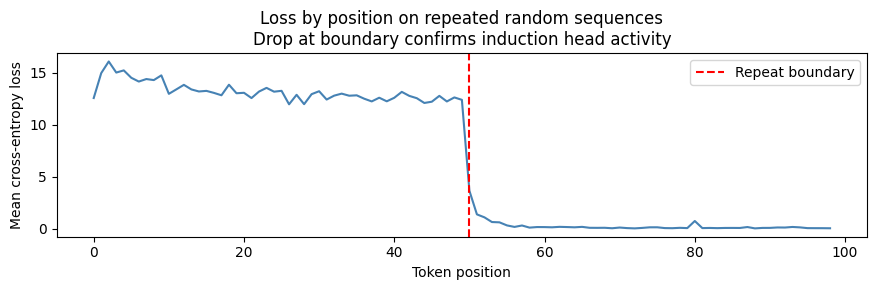

In [9]:
# Verification: on repeated random sequences, loss should drop sharply at
# position SEQ_LEN. Before the repeat boundary the model cannot use induction;
# after it, induction heads allow near-perfect prediction of the repeated half.
with torch.no_grad():
    rep_logits = model(repeated)
    loss_by_pos = model.loss_fn(rep_logits, repeated, per_token = True).mean(0).cpu().numpy()

plt.figure(figsize = (9, 3))
plt.plot(loss_by_pos, color = 'steelblue')
plt.axvline(SEQ_LEN, color = 'red', linestyle = '--', label = 'Repeat boundary')
plt.xlabel('Token position')
plt.ylabel('Mean cross-entropy loss')
plt.title('Loss by position on repeated random sequences\nDrop at boundary confirms induction head activity')
plt.legend()
plt.tight_layout()
plt.savefig('figures/induction_loss.png', dpi = 120, bbox_inches = 'tight')
plt.show()

---
# 4. Logit Lens

In [10]:
def logit_lens(prompt, correct_token):
    """Probe the residual stream layer-by-layer.

    Returns:
        labels       : list of checkpoint labels ('embed', '0', '1', ..., '11')
        correct_probs: probability of correct_token at each checkpoint
        top1_tokens  : top-1 predicted token string at each checkpoint
        top1_probs   : top-1 token probability at each checkpoint
    """
    correct_id = model.to_single_token(correct_token)
    _, cache = model.run_with_cache(prompt)

    # accumulated_resid returns residual stream at the input to each layer,
    # plus the final output. Shape: [n_checkpoints, batch, seq, d_model]
    # pos_slice=-1 selects the final token position only.
    resid_stack, labels = cache.accumulated_resid(
        layer = -1, incl_mid = False, pos_slice = -1, return_labels = True
    )
    # Apply final LayerNorm, then unembed to vocab space
    resid_stack = model.ln_final(resid_stack)       # [n_checkpoints, 1, d_model]
    logit_stack = model.unembed(resid_stack)         # [n_checkpoints, 1, vocab]
    prob_stack  = torch.softmax(logit_stack, dim=-1) # [n_checkpoints, 1, vocab]

    correct_probs = prob_stack[:, 0, correct_id].detach().cpu().numpy()
    top1_probs    = prob_stack[:, 0].max(dim = -1).values.detach().cpu().numpy()
    top1_tokens   = [
        model.to_single_str_token(prob_stack[i, 0].argmax().item())
        for i in range(len(labels))
    ]

    return labels, correct_probs, top1_tokens, top1_probs


LL_PROMPT  = 'The Eiffel Tower is located in the city of'
LL_CORRECT = ' Paris'

labels, correct_probs, top1, top1_probs = logit_lens(LL_PROMPT, LL_CORRECT)

print(f'Prompt: "{LL_PROMPT}"')
print(f'Correct token: {repr(LL_CORRECT)}\n')
print(f'{"Checkpoint":>12}   {"Top-1 pred":>15}   {"P(correct)":>10}')
print('-' * 44)
for label, prob, tok in zip(labels, correct_probs, top1):
    flag = ' <--' if tok == LL_CORRECT else ''
    print(f'{label:>12}   {repr(tok):>15}   {prob:>10.4f}{flag}')

Prompt: "The Eiffel Tower is located in the city of"
Correct token: ' Paris'

  Checkpoint        Top-1 pred   P(correct)
--------------------------------------------
       0_pre         ' destro'       0.0000
       1_pre            ' the'       0.0000
       2_pre            ' the'       0.0000
       3_pre            ' the'       0.0000
       4_pre            ' the'       0.0000
       5_pre            ' the'       0.0001
       6_pre        ' England'       0.0003
       7_pre          ' South'       0.0006
       8_pre            ' Ing'       0.0011
       9_pre        ' Chicago'       0.0152
      10_pre         ' London'       0.1549
      11_pre         ' London'       0.1374
  final_post         ' London'       0.0688


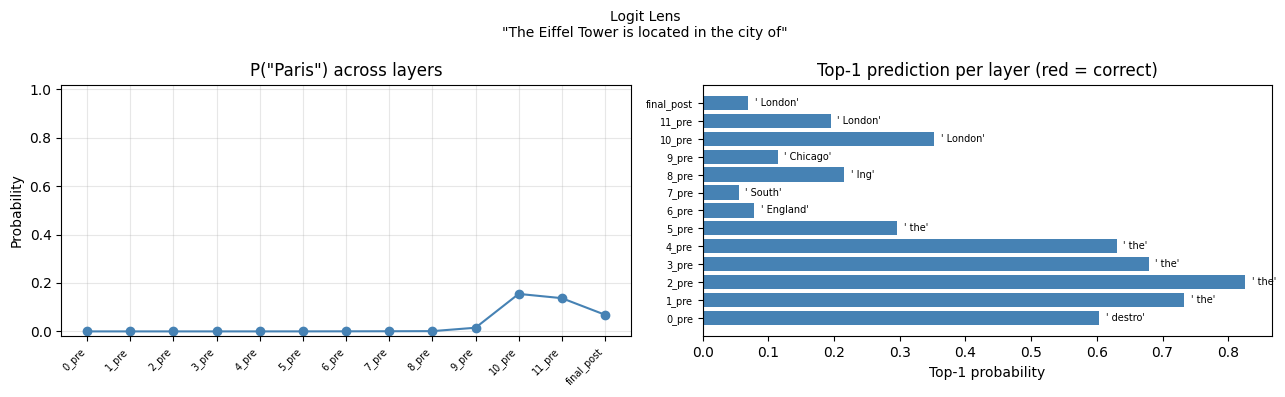

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4))
fig.suptitle(f'Logit Lens\n"{LL_PROMPT}"', fontsize = 10)

# Left: correct token probability across checkpoints
axes[0].plot(range(len(labels)), correct_probs, 'o-', color = 'steelblue')
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 7)
axes[0].set_ylabel('Probability')
axes[0].set_title(f'P("{LL_CORRECT.strip()}") across layers')
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(True, alpha = 0.3)

# Right: top-1 prediction and its probability at each checkpoint
colors = ['red' if t == LL_CORRECT else 'steelblue' for t in top1]
axes[1].barh(range(len(labels)), top1_probs, color = colors)
for i, tok in enumerate(top1):
    axes[1].text(top1_probs[i] + 0.01, i, repr(tok), va = 'center', fontsize = 7)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels, fontsize = 7)
axes[1].set_xlabel('Top-1 probability')
axes[1].set_title('Top-1 prediction per layer (red = correct)')

plt.tight_layout()
plt.savefig('figures/logit_lens.png', dpi = 120, bbox_inches = 'tight')
plt.show()

---
# 5. Activation Patching: Indirect Object Identification (IOI) 

In [12]:
# Template from Wang et al. (2022): subject (S) listed first, then indirect object (IO)
CLEAN     = 'When John and Mary went to the store, John gave a bottle of milk to'
CORRUPTED = 'When John and Mary went to the store, Mary gave a bottle of milk to'

clean_tokens     = model.to_tokens(CLEAN)
corrupted_tokens = model.to_tokens(CORRUPTED)

IO_TOKEN = model.to_single_token(' Mary')  # indirect object
S_TOKEN  = model.to_single_token(' John')  # subject

clean_logits,     clean_cache     = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)


def logit_diff(logits):
    """logit(IO) - logit(S) at the final token position."""
    return (logits[0, -1, IO_TOKEN] - logits[0, -1, S_TOKEN]).item()


clean_ld     = logit_diff(clean_logits)
corrupted_ld = logit_diff(corrupted_logits)

print(f'Clean logit diff     (positive = model predicts Mary): {clean_ld:+.3f}')
print(f'Corrupted logit diff (negative = model predicts John): {corrupted_ld:+.3f}')


def normalized_ld(patched_logits):
    """1.0 = fully restored to clean, 0.0 = still at corrupted baseline."""
    return (logit_diff(patched_logits) - corrupted_ld) / (clean_ld - corrupted_ld)

Clean logit diff     (positive = model predicts Mary): +3.481
Corrupted logit diff (negative = model predicts John): -4.372


In [ ]:
# Residual stream patching: at each (layer, position), replace the corrupted
# residual stream value with the corresponding clean value.
seq_len = clean_tokens.shape[1]
resid_patch = torch.zeros(n_layers, seq_len)

for layer in range(n_layers):
    for pos in range(seq_len):
        def resid_hook(resid, hook, layer = layer, pos = pos):
            resid[:, pos, :] = clean_cache[f'blocks.{layer}.hook_resid_pre'][:, pos, :]
            return resid

        patched = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks = [(f'blocks.{layer}.hook_resid_pre', resid_hook)],
            return_type='logits'
        )
        resid_patch[layer, pos] = normalized_ld(patched)

print('Residual stream patching done.')

Residual stream patching done.


In [ ]:
# Attention head output patching: at each (layer, head), replace the head's 
# pre-W_O output (z), the per-head value vector before projection at the final token position with the clean value.
head_patch = torch.zeros(n_layers, n_heads)

for layer in range(n_layers):
    for head in range(n_heads):
        def head_hook(z, hook, layer = layer, head = head):
            z[:, -1, head, :] = clean_cache[f'blocks.{layer}.attn.hook_z'][:, -1, head, :]
            return z

        patched = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks = [(f'blocks.{layer}.attn.hook_z', head_hook)],
            return_type = 'logits'
        )
        head_patch[layer, head] = normalized_ld(patched)

print('Attention head patching done.')

Attention head patching done.


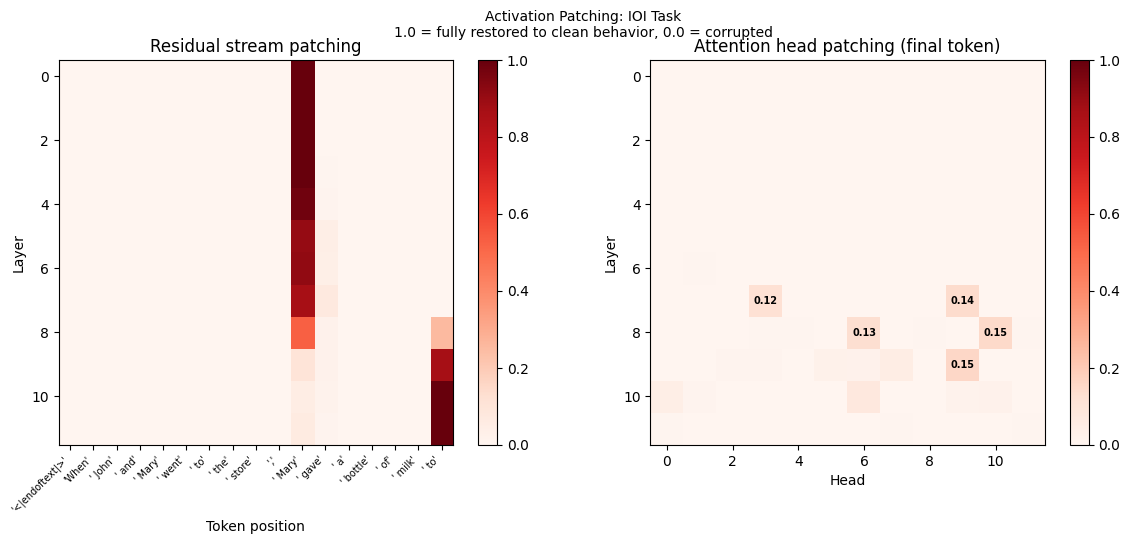

In [ ]:
token_labels = model.to_str_tokens(CORRUPTED)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle('Activation Patching: IOI Task\n'
             '1.0 = fully restored to clean behavior, 0.0 = corrupted', fontsize = 10)

im1 = axes[0].imshow(resid_patch.detach().cpu().numpy(), cmap = 'Reds', vmin = 0, vmax = 1, aspect = 'auto')
axes[0].set_xlabel('Token position')
axes[0].set_ylabel('Layer')
axes[0].set_title('Residual stream patching')
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels([repr(t) for t in token_labels], rotation = 45, ha = 'right', fontsize = 7)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(head_patch.detach().cpu().numpy(), cmap = 'Reds', vmin = 0, vmax = 1, aspect = 'auto')
axes[1].set_xlabel('Head')
axes[1].set_ylabel('Layer')
axes[1].set_title('Attention head patching (final token)')
plt.colorbar(im2, ax = axes[1])

# Label top 5 heads
flat = head_patch.numpy().flatten()
for idx in np.argsort(flat)[-5:]:
    l, h = divmod(idx, n_heads)
    score = flat[idx]
    text_color = 'white' if score > 0.5 else 'black'
    axes[1].text(h, l, f'{score:.2f}', ha = 'center', va = 'center',
                 fontsize = 7, color = text_color, fontweight = 'bold')

> Note: In GPT-2 Small's IOI circuit, no single head dominates. The behavior is distributed across many heads. Patching any one head in isolation restores only a small fraction (~10-15%) of clean behavior. This is consistent with Wang et al. (2022), who identify a multi-head circuit rather than a single responsible component. The residual stream patching (left) is more informative here.

---
# 6. Direct Logit Attribution (DLA)

In [17]:
DLA_PROMPT = 'When John and Mary went to the store, John gave a bottle of milk to'
DLA_TARGET = ' Mary'

target_id    = model.to_single_token(DLA_TARGET)
_, dla_cache = model.run_with_cache(DLA_PROMPT)

W_U_dir = model.W_U[:, target_id]

head_dla = torch.zeros(n_layers, n_heads)
mlp_dla  = torch.zeros(n_layers)

for layer in range(n_layers):
    # hook_z: [batch, seq, n_heads, d_head]
    # W_O: [n_heads, d_head, d_model]
    z   = dla_cache[f'blocks.{layer}.attn.hook_z'][0, -1]   # [n_heads, d_head]
    W_O = model.blocks[layer].attn.W_O                       # [n_heads, d_head, d_model]
    result = einops.einsum(z, W_O, 'h d, h d m -> h m')     # [n_heads, d_model]
    head_dla[layer] = einops.einsum(result, W_U_dir, 'h d, d -> h')

    mlp_out = dla_cache[f'blocks.{layer}.hook_mlp_out'][0, -1]
    mlp_dla[layer] = (mlp_out * W_U_dir).sum()

print('DLA computed.')
print('Top 5 attention heads by absolute DLA:')
flat = head_dla.detach().numpy().flatten()
for idx in np.argsort(np.abs(flat))[-5:][::-1]:
    l, h = divmod(idx, n_heads)
    print(f'  L{l}H{h}: {flat[idx]:+.3f}')

DLA computed.
Top 5 attention heads by absolute DLA:
  L9H9: +54.357
  L10H7: -45.970
  L9H6: +43.034
  L11H10: -32.967
  L10H0: +18.014


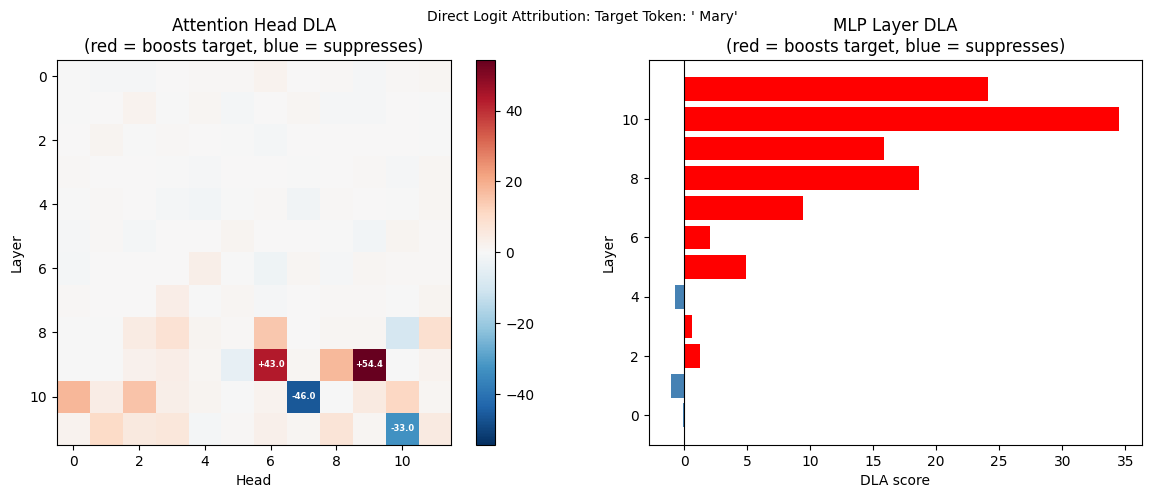

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle(f'Direct Logit Attribution: Target Token: {repr(DLA_TARGET)}', fontsize = 10)

vmax = head_dla.abs().max().item()
im = axes[0].imshow(head_dla.detach().numpy(), cmap = 'RdBu_r', vmin = -vmax, vmax = vmax, aspect = 'auto')
axes[0].set_xlabel('Head')
axes[0].set_ylabel('Layer')
axes[0].set_title('Attention Head DLA\n(red = boosts target, blue = suppresses)')
plt.colorbar(im, ax = axes[0])

# Annotate extreme heads
for l in range(n_layers):
    for h in range(n_heads):
        if abs(head_dla[l, h].item()) > vmax * 0.5:
            axes[0].text(h, l, f'{head_dla[l,h].item():+.1f}',
                         ha='center', va='center', fontsize=6,
                         color='white', fontweight='bold')

mlp_vals = mlp_dla.detach().numpy()
colors   = ['red' if v > 0 else 'steelblue' for v in mlp_vals]
axes[1].barh(range(n_layers), mlp_vals, color = colors)
axes[1].axvline(0, color = 'black', linewidth = 0.8)
axes[1].set_xlabel('DLA score')
axes[1].set_ylabel('Layer')
axes[1].set_title('MLP Layer DLA\n(red = boosts target, blue = suppresses)')

plt.savefig('figures/direct_logit_attribution.png', dpi = 120, bbox_inches = 'tight')
plt.show()